# Day 1 Lab 1 — Baselines, preprocessing, and a first defensible CHF regression workflow

## Purpose
This lab is the first hands-on modelling exercise of the **AI for Nuclear Thermal Hydraulics Summer School**.

The goal is **not** to build the most accurate model possible.  
Instead, the goal is to practise a **correct and defensible supervised-learning workflow** for a structured engineering prediction problem.

## Learning goals
By the end of this lab, you should be able to:

- load the CHF case-study data correctly;
- use the organiser-provided train / validation / test split;
- define inputs (`X`) and target (`y`);
- build a simple preprocessing + model pipeline;
- compare a naive baseline with **Linear Regression** and **Ridge Regression**;
- evaluate the models using basic metrics and diagnostic plots;
- write a short engineering interpretation of the results.

## Expected outputs
By the end of the lab, you should have:

1. a working baseline notebook;
2. a naive baseline result;
3. a Linear Regression result;
4. a Ridge Regression result;
5. a parity plot;
6. a residual plot;
7. a short written interpretation of model limitations.

## Case study
The running case study is **CHF prediction** from structured thermal-hydraulics data.

Throughout this notebook:
- the **target** is expected to be `CHF`;
- the remaining selected variables are candidate input features.

> Important: Day 1 is about **workflow discipline**.  
> A simple but correct workflow is better than a complex but invalid one.

## HTML widget for data visualisation
To use the HTML widget for data visualisation:
- Right-click the **chf_3d_multi_csv_viewer.html** file in the left-hand file browser.

- Click on "Open in New Browser Tab"

## 1. Imports and environment check

Run this cell first. It checks the core packages needed for Day 1.

In [1]:
from pathlib import Path
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Python executable :", sys.executable)
print("Python version    :", platform.python_version())
print("Platform          :", platform.platform())
print("\nCore imports succeeded.")

Python executable : /home/marlen/anaconda3/envs/ai-nth-summerschool/bin/python
Python version    : 3.11.15
Platform          : Linux-6.8.0-124-generic-x86_64-with-glibc2.39

Core imports succeeded.


## 2. Locate the notebook and dataset folders

This notebook is assumed to live in:

`./AI_NTH_Bundle/course_materials/day1_foundations`

and the case-study CSV files are assumed to be in:

`./AI_NTH_Bundle/datasets`

So, relative to this notebook, the dataset folder should be found at:

`../../datasets`


In [ ]:
notebook_dir = Path.cwd().resolve()
bundle_root = notebook_dir.parents[1]
data_dir = bundle_root / "datasets"

print("Notebook directory :", notebook_dir)
print("Bundle root        :", bundle_root)
print("Dataset directory  :", data_dir)

assert data_dir.exists(), f"Dataset directory not found: {data_dir}"
print("\nPASS: dataset directory exists.")


## 3. Specify the data files

This notebook supports two common organiser workflows:

### Option A — one master file + one split-assignment file
- `master_data_file`: one CSV containing all rows
- `split_file`: one CSV containing at least:
  - `sample_id`
  - `split` (`train`, `val`, `test`)

### Option B — separate train / validation / test files
- `train_file`
- `val_file`
- `test_file`

Please edit the filenames below to match the actual files in your `datasets` folder.

> Only one of the two options needs to be used.

In [3]:
# =========================
# EDIT THESE FILENAMES
# =========================

# Option A: pre-split data files (will be used in this training)
train_file = "chf_train.csv"
val_file = "chf_val.csv"
test_file = "chf_test.csv"

# Option A: master data + split assignment (can try with people's own dataset)
master_data_file = "chf_master.csv"
split_file = "chf_split_baseline.csv"
# Optional unique ID column if using a split assignment file
id_col = "sample_id"

# Target column name
target_col = "CHF (kW/m^2)"

## 4. Load the data

The cell below first tries **Option A** (pre-split train/val/test files). 

If those files are not found, it tries **Option B** (master file + split assignment). 

If neither works, please check the filenames in the previous cell.

In [4]:
def try_load_option_a(data_dir, train_file, val_file, test_file):
    train_path = data_dir / train_file
    val_path = data_dir / val_file
    test_path = data_dir / test_file
    if train_path.exists() and val_path.exists() and test_path.exists():
        train_df = pd.read_csv(train_path)
        val_df = pd.read_csv(val_path)
        test_df = pd.read_csv(test_path)
        return train_df, val_df, test_df, "Option B"
    return None

def try_load_option_b(data_dir, master_data_file, split_file, id_col):
    master_path = data_dir / master_data_file
    split_path = data_dir / split_file
    if master_path.exists() and split_path.exists():
        df_master = pd.read_csv(master_path)
        df_split = pd.read_csv(split_path)
        assert id_col in df_master.columns, f"'{id_col}' not found in master data."
        assert id_col in df_split.columns, f"'{id_col}' not found in split file."
        assert "split" in df_split.columns, "'split' column not found in split file."

        df_all = df_master.merge(df_split[[id_col, "split"]], on=id_col, how="inner")
        train_df = df_all[df_all["split"].str.lower() == "train"].copy()
        val_df = df_all[df_all["split"].str.lower().isin(["val", "valid", "validation"])].copy()
        test_df = df_all[df_all["split"].str.lower() == "test"].copy()
        return train_df, val_df, test_df, "Option A"
    return None

loaded = try_load_option_a(data_dir, train_file, val_file, test_file)
if loaded is None:
    loaded =  try_load_option_b(data_dir, master_data_file, split_file, id_col)

if loaded is None:
    raise FileNotFoundError(
        "Could not find a valid Day 1 data configuration. "
        "Please edit the filenames in Section 3."
    )

train_df, val_df, test_df, load_mode = loaded
print(f"Loaded data using {load_mode}")
print(f"Train shape: {train_df.shape}")
print(f"Val shape  : {val_df.shape}")
print(f"Test shape : {test_df.shape}")

Loaded data using Option B
Train shape: (10424, 11)
Val shape  : (3150, 11)
Test shape : (2307, 11)


## 5. Quick inspection of the data

Before modelling, inspect the shape, columns, and a few rows.

This is part of good engineering practice:
- confirm that the data loaded as expected;
- check that the target exists;
- understand the structure of the table.

In [5]:
assert target_col in train_df.columns, f"Target column '{target_col}' not found in training data."

print("Columns in the dataset:")
for c in train_df.columns:
    print("-", c)

print("\nTraining data preview:")
display(train_df.head())

print("\nMissing values in training data:")
display(train_df.isna().sum().to_frame("missing_values").T)

Columns in the dataset:
- Number
- Reference ID
- Tube Diameter (m)
- Heated Length (m)
- Pressure (kPa)
- Mass Flux (kg/m^2/s)
- Outlet Quality
- Inlet Subcooling (kJ/kg)
- Inlet Temperature (degreeC )
- CHF (kW/m^2)
- Reference name

Training data preview:


,Number,Reference ID,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC ),CHF (kW/m^2),Reference name
0,1650,9,0.00999,0.6,2991.0,220.0,0.751,839.0,39.61,2002.0,"Becker 1963 AE 114, 1965 AE-177"
1,1651,9,0.00999,0.6,2305.0,225.0,0.737,776.0,39.16,2009.0,"Becker 1963 AE 114, 1965 AE-177"
2,1652,9,0.00999,0.6,2599.0,221.0,0.750,812.0,37.54,2009.0,"Becker 1963 AE 114, 1965 AE-177"
3,1653,9,0.00999,0.6,2040.0,228.0,0.725,749.0,38.75,2006.0,"Becker 1963 AE 114, 1965 AE-177"
4,1654,9,0.00999,0.6,1775.0,228.0,0.726,717.0,38.86,1998.0,"Becker 1963 AE 114, 1965 AE-177"



Missing values in training data:


,Number,Reference ID,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC ),CHF (kW/m^2),Reference name
missing_values,0,0,0,0,0,0,0,0,0,0,0


## 6. Define features and target

For Day 1, keep the feature definition simple and explicit.

### Default policy
- **Target** = `CHF (kW/m^2)`
- Candidate features = all remaining columns, excluding split/ID helper columns

You may later refine the feature set, but on Day 1 the main goal is to learn the workflow rather than optimise the feature engineering.

In [6]:
excluded_cols = {target_col, "split", id_col}
feature_cols = ["Pressure (kPa)", "Mass Flux (kg/m^2/s)", "Outlet Quality", ]
#feature_cols = [c for c in train_df.columns if c not in excluded_cols]

print("Selected feature columns:")
for c in feature_cols:
    print("-", c)

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Selected feature columns:
- Pressure (kPa)
- Mass Flux (kg/m^2/s)
- Outlet Quality

Shapes:
X_train: (10424, 3) y_train: (10424,)
X_val  : (3150, 3) y_val  : (3150,)
X_test : (2307, 3) y_test : (2307,)


## 7. Identify numeric and non-numeric columns

This helps us build an appropriate preprocessing pipeline.

For Day 1, the simplest robust approach is:
- impute missing values;
- scale numeric variables;
- pass through or lightly handle non-numeric variables if present.

If all features are numeric, the pipeline becomes simpler.

In [7]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Number of numeric columns    :", len(numeric_cols))
print("Number of non-numeric columns:", len(categorical_cols))

print("\nNumeric columns:")
print(numeric_cols)

print("\nNon-numeric columns:")
print(categorical_cols)

Number of numeric columns    : 3
Number of non-numeric columns: 0

Numeric columns:
['Pressure (kPa)', 'Mass Flux (kg/m^2/s)', 'Outlet Quality']

Non-numeric columns:
[]


## 8. Naive baseline

Before fitting any ML model, compare against a trivial baseline.

A simple naive baseline for regression is:
- predict the **training mean CHF** for every case

This gives a reference point:
- if the ML model cannot beat this baseline, something is wrong;
- if it only slightly beats this baseline, the problem may still be hard or the model too simple.

In [8]:
y_train_mean = y_train.mean()

naive_pred_val = np.full(shape=len(y_val), fill_value=y_train_mean)
naive_pred_test = np.full(shape=len(y_test), fill_value=y_train_mean)

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

naive_val_metrics = regression_metrics(y_val, naive_pred_val)
naive_test_metrics = regression_metrics(y_test, naive_pred_test)

print("Naive baseline (predict training mean CHF)")
print("Validation:", naive_val_metrics)
print("Test      :", naive_test_metrics)

Naive baseline (predict training mean CHF)
Validation: {'MAE': 913.3031720206119, 'RMSE': 1146.3516640070893, 'R2': -0.0221108269120458}
Test      : {'MAE': 861.9335143575179, 'RMSE': 979.8072303048766, 'R2': -0.4335268318209562}


## 9. Build a preprocessing pipeline

For Day 1, we use a simple and defensible pipeline:
- numeric columns:
  - median imputation
  - standard scaling
- non-numeric columns:
  - most-frequent imputation

This keeps the workflow clean and helps avoid leakage by placing preprocessing inside the pipeline.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

if categorical_cols:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop"
    )
else:
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
        ],
        remainder="drop"
    )

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 10. Train a Linear Regression model

This is the first supervised baseline model.

The point is not that Linear Regression will be the best model for CHF prediction.  
The point is that it provides:
- a transparent baseline;
- a useful reference for later methods;
- a simple model that makes workflow issues easier to see.

In [10]:
linear_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train)

linear_val_pred = linear_model.predict(X_val)
linear_test_pred = linear_model.predict(X_test)

linear_val_metrics = regression_metrics(y_val, linear_val_pred)
linear_test_metrics = regression_metrics(y_test, linear_test_pred)

print("Linear Regression")
print("Validation:", linear_val_metrics)
print("Test      :", linear_test_metrics)

Linear Regression
Validation: {'MAE': 579.293038740767, 'RMSE': 743.6035148289329, 'R2': 0.5699240819817886}
Test      : {'MAE': 654.7524342758949, 'RMSE': 819.8758237286529, 'R2': -0.003738787294383039}


## 11. Train a Ridge Regression model

Ridge Regression adds L2 regularisation.

This is still a simple baseline model, but it can sometimes behave more robustly than plain Linear Regression, especially when inputs are correlated or noisy.

In [11]:
ridge_alpha = 1.0  # You may change this later if desired

ridge_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=ridge_alpha)),
])

ridge_model.fit(X_train, y_train)

ridge_val_pred = ridge_model.predict(X_val)
ridge_test_pred = ridge_model.predict(X_test)

ridge_val_metrics = regression_metrics(y_val, ridge_val_pred)
ridge_test_metrics = regression_metrics(y_test, ridge_test_pred)

print("Ridge Regression")
print("Validation:", ridge_val_metrics)
print("Test      :", ridge_test_metrics)

Ridge Regression
Validation: {'MAE': 579.2380431027585, 'RMSE': 743.5439330489529, 'R2': 0.5699929995208064}
Test      : {'MAE': 654.6295509085658, 'RMSE': 819.7146555604417, 'R2': -0.003344203536986612}


## 12. Compare baseline results

This table compares:
- naive baseline
- Linear Regression
- Ridge Regression

Use it as a first engineering comparison, not as the final word on model choice.

In [12]:
comparison = pd.DataFrame({
    "MAE": [
        naive_val_metrics["MAE"], linear_val_metrics["MAE"], ridge_val_metrics["MAE"],
        naive_test_metrics["MAE"], linear_test_metrics["MAE"], ridge_test_metrics["MAE"]
    ],
    "RMSE": [
        naive_val_metrics["RMSE"], linear_val_metrics["RMSE"], ridge_val_metrics["RMSE"],
        naive_test_metrics["RMSE"], linear_test_metrics["RMSE"], ridge_test_metrics["RMSE"]
    ],
    "R2": [
        naive_val_metrics["R2"], linear_val_metrics["R2"], ridge_val_metrics["R2"],
        naive_test_metrics["R2"], linear_test_metrics["R2"], ridge_test_metrics["R2"]
    ],
}, index=[
    "Naive (Val)", "Linear (Val)", "Ridge (Val)",
    "Naive (Test)", "Linear (Test)", "Ridge (Test)"
])

display(comparison)

,MAE,RMSE,R2
Naive (Val),913.303172,1146.351664,-0.022111
Linear (Val),579.293039,743.603515,0.569924
Ridge (Val),579.238043,743.543933,0.569993
Naive (Test),861.933514,979.807230,-0.433527
Linear (Test),654.752434,819.875824,-0.003739
Ridge (Test),654.629551,819.714656,-0.003344


## 13. Plot 1 — Parity plot

A parity plot compares predicted vs observed CHF.

A perfect model would place all points on the diagonal line.

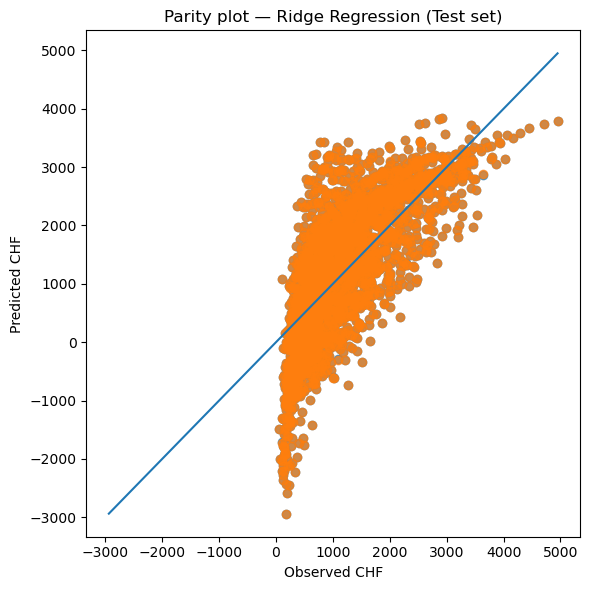

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, ridge_test_pred, alpha=0.7)
plt.scatter(y_test, linear_test_pred, alpha=0.7)
lims = [
    min(float(np.min(y_test)), float(np.min(ridge_test_pred))),
    max(float(np.max(y_test)), float(np.max(ridge_test_pred))),
]
plt.plot(lims, lims)
plt.xlabel("Observed CHF")
plt.ylabel("Predicted CHF")
plt.title("Parity plot — Ridge Regression (Test set)")
plt.tight_layout()
plt.show()

## 14. Plot 2 — Residual plot

Residuals = observed − predicted

This plot can help reveal:
- systematic bias,
- heteroscedasticity,
- regions where the model struggles.

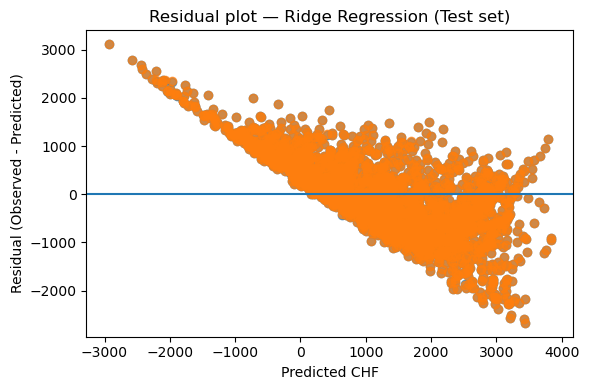

In [14]:
ridge_test_residuals = y_test - ridge_test_pred
linear_test_residuals = y_test - linear_test_pred
plt.figure(figsize=(6, 4))
plt.scatter(ridge_test_pred, ridge_test_residuals, alpha=0.7)
plt.scatter(ridge_test_pred, linear_test_residuals, alpha=0.7)
plt.axhline(0.0)
plt.xlabel("Predicted CHF")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Residual plot — Ridge Regression (Test set)")
plt.tight_layout()
plt.show()

## 15. Optional check — compare Linear vs Ridge visually

This is optional, but useful if you want to see whether the two simple baselines behave differently in practice.

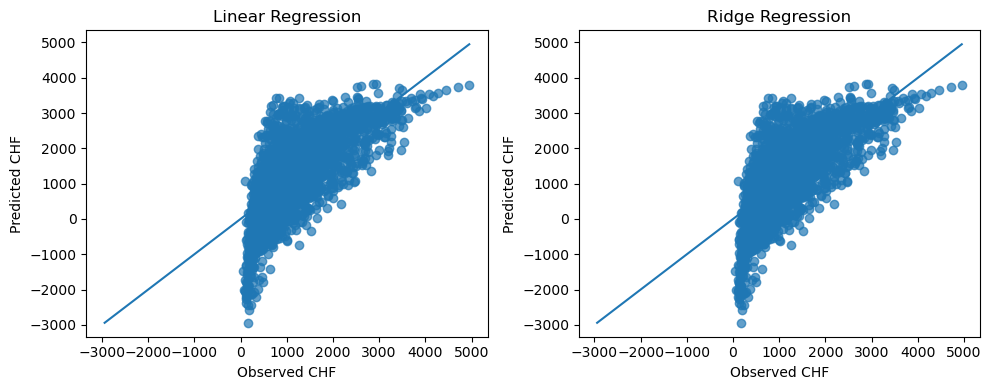

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

lims = [
    min(float(np.min(y_test)), float(np.min(linear_test_pred)), float(np.min(ridge_test_pred))),
    max(float(np.max(y_test)), float(np.max(linear_test_pred)), float(np.max(ridge_test_pred))),
]

axes[0].scatter(y_test, linear_test_pred, alpha=0.7)
axes[0].plot(lims, lims)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Observed CHF")
axes[0].set_ylabel("Predicted CHF")

axes[1].scatter(y_test, ridge_test_pred, alpha=0.7)
axes[1].plot(lims, lims)
axes[1].set_title("Ridge Regression")
axes[1].set_xlabel("Observed CHF")
axes[1].set_ylabel("Predicted CHF")

plt.tight_layout()
plt.show()

## 16. Short interpretation questions

Please answer these questions briefly in markdown below:

1. Does Linear / Ridge Regression beat the naive baseline?
2. Which simple model looks better on the validation and test sets?
3. What patterns do you notice in the parity plot and residual plot?
4. Would you trust this as a final engineering model for CHF prediction? Why or why not?
5. What limitations of this baseline workflow should be addressed by later methods?

You can write your answers in the cell below.

In [16]:
# Write your brief interpretation here.
#
# Example structure:
# 1. Baseline comparison:
# 2. Plot interpretation:
# 3. Trust / limitations:
#

## 17. Optional extension — a simple failure-mode reminder

If time permits, the instructor may demonstrate one of the following:
- what happens with a bad split;
- what happens if preprocessing is done incorrectly outside the pipeline;
- what happens if the target leaks into the features.

This is optional and is not required for a complete Day 1 lab.

### Failure-mode demo 1 — Bad split

Here we compare:

- a **correct organiser-defined split**, and
- a **naive random row split**

The point is not that random splitting is always wrong, but that for engineering data with grouped sources or clustered operating conditions, it can produce **over-optimistic performance estimates**.

In [17]:
from sklearn.model_selection import train_test_split

# --- 1. Build a naive random split from the combined Day 1 data ---
df_all_bad_demo = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

X_all_bad = df_all_bad_demo[feature_cols].copy()
y_all_bad = df_all_bad_demo[target_col].copy()

X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X_all_bad, y_all_bad, test_size=0.2, random_state=42, shuffle=True
)

# --- 2. Use the same preprocessing + Ridge model structure ---
bad_split_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

bad_split_model.fit(X_train_bad, y_train_bad)
bad_split_pred = bad_split_model.predict(X_test_bad)

bad_split_metrics = regression_metrics(y_test_bad, bad_split_pred)

print("Naive random-row split metrics:")
print(bad_split_metrics)

print("\nCorrect organiser-defined test metrics (Ridge):")
print(ridge_test_metrics)

Naive random-row split metrics:
{'MAE': 569.4135447524744, 'RMSE': 751.1913290329328, 'R2': 0.6219370055865647}

Correct organiser-defined test metrics (Ridge):
{'MAE': 654.6295509085658, 'RMSE': 819.7146555604417, 'R2': -0.003344203536986612}


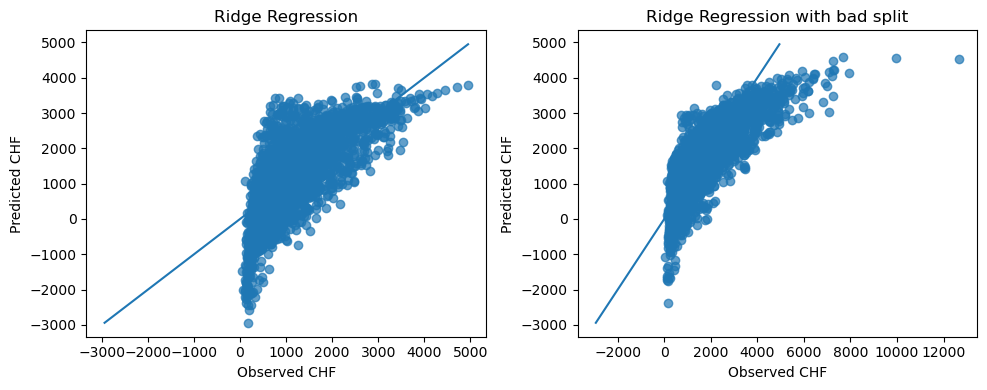

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

lims = [
    min(float(np.min(y_test)), float(np.min(linear_test_pred)), float(np.min(ridge_test_pred))),
    max(float(np.max(y_test)), float(np.max(linear_test_pred)), float(np.max(ridge_test_pred))),
]

axes[0].scatter(y_test, ridge_test_pred, alpha=0.7)
axes[0].plot(lims, lims)
axes[0].set_title("Ridge Regression")
axes[0].set_xlabel("Observed CHF")
axes[0].set_ylabel("Predicted CHF")

axes[1].scatter(y_test_bad, bad_split_pred, alpha=0.7)
axes[1].plot(lims, lims)
axes[1].set_title("Ridge Regression with bad split")
axes[1].set_xlabel("Observed CHF")
axes[1].set_ylabel("Predicted CHF")

plt.tight_layout()
plt.show()

### Discussion
- Does the naive random split make the model look better?
- Why might that happen in a multi-source engineering dataset?
- Which result should be trusted more for comparing models across the summer school?

## Failure-mode demo 2 — Preprocessing outside the pipeline

In the correct workflow, preprocessing is fit on the **training data only** and placed inside the pipeline.

Here we deliberately do something wrong:
- we fit the imputer and scaler on the **combined train + validation + test data**
- then we train the model on transformed training data

This leaks information from the evaluation sets into model development.

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Numeric-only version for a simple demo
demo_numeric_cols = numeric_cols.copy()

X_train_num = X_train[demo_numeric_cols].copy()
X_val_num = X_val[demo_numeric_cols].copy()
X_test_num = X_test[demo_numeric_cols].copy()

# --- WRONG: fit preprocessing on all splits together ---
X_all_num = pd.concat([X_train_num, X_val_num, X_test_num], axis=0)

wrong_imputer = SimpleImputer(strategy="median")
wrong_scaler = StandardScaler()

X_all_imputed = wrong_imputer.fit_transform(X_all_num)
X_all_scaled = wrong_scaler.fit_transform(X_all_imputed)

n_train = len(X_train_num)
n_val = len(X_val_num)

X_train_wrong = X_all_scaled[:n_train]
X_val_wrong = X_all_scaled[n_train:n_train+n_val]
X_test_wrong = X_all_scaled[n_train+n_val:]

wrong_ridge = Ridge(alpha=1.0)
wrong_ridge.fit(X_train_wrong, y_train)

wrong_val_pred = wrong_ridge.predict(X_val_wrong)
wrong_test_pred = wrong_ridge.predict(X_test_wrong)

wrong_val_metrics = regression_metrics(y_val, wrong_val_pred)
wrong_test_metrics = regression_metrics(y_test, wrong_test_pred)

print("WRONG preprocessing outside pipeline")
print("Validation:", wrong_val_metrics)
print("Test      :", wrong_test_metrics)

print("\nCORRECT Ridge pipeline")
print("Validation:", ridge_val_metrics)
print("Test      :", ridge_test_metrics)

WRONG preprocessing outside pipeline
Validation: {'MAE': 579.2297922854796, 'RMSE': 743.5355169405358, 'R2': 0.5700027338885924}
Test      : {'MAE': 654.6122673946269, 'RMSE': 819.69204696352, 'R2': -0.00328885771221632}

CORRECT Ridge pipeline
Validation: {'MAE': 579.2380431027585, 'RMSE': 743.5439330489529, 'R2': 0.5699929995208064}
Test      : {'MAE': 654.6295509085658, 'RMSE': 819.7146555604417, 'R2': -0.003344203536986612}


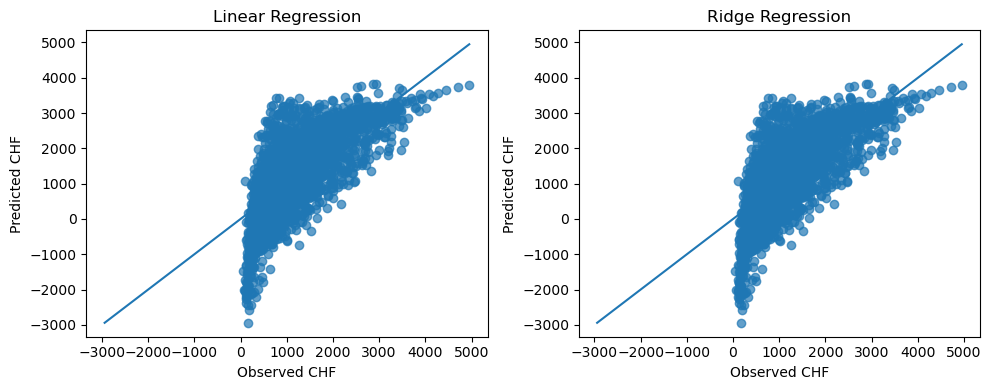

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

lims = [
    min(float(np.min(y_test)), float(np.min(linear_test_pred)), float(np.min(ridge_test_pred))),
    max(float(np.max(y_test)), float(np.max(linear_test_pred)), float(np.max(ridge_test_pred))),
]

axes[0].scatter(y_test, ridge_test_pred, alpha=0.7)
axes[0].plot(lims, lims)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Observed CHF")
axes[0].set_ylabel("Predicted CHF")

axes[1].scatter(y_test, wrong_test_pred, alpha=0.7)
axes[1].plot(lims, lims)
axes[1].set_title("Ridge Regression")
axes[1].set_xlabel("Observed CHF")
axes[1].set_ylabel("Predicted CHF")

plt.tight_layout()
plt.show()

### Discussion
- Are the numbers similar, or does the wrong workflow look slightly better?
- Even if the effect is small here, why is this still incorrect?
- Why is using a pipeline the safer engineering practice?

## Failure-mode demo 3. — Target leakage

### 3.1 Here we deliberately create a leaking feature by adding a near-copy of the target to the feature table.

This is an intentionally incorrect workflow.  
The purpose is to show how a model can appear “amazing” for completely invalid reasons.

In [21]:
# Copy the original feature sets
X_train_leaky = X_train.copy()
X_val_leaky = X_val.copy()
X_test_leaky = X_test.copy()

# DELIBERATE LEAKAGE:
# Add a near-copy of the target as an input feature
rng = np.random.default_rng(42)
X_train_leaky["CHF_leaky_feature"] = y_train + rng.normal(0, 1e-6, size=len(y_train))
X_val_leaky["CHF_leaky_feature"] = y_val + rng.normal(0, 1e-6, size=len(y_val))
X_test_leaky["CHF_leaky_feature"] = y_test + rng.normal(0, 1e-6, size=len(y_test))

leaky_numeric_cols = X_train_leaky.select_dtypes(include=[np.number]).columns.tolist()
leaky_categorical_cols = [c for c in X_train_leaky.columns if c not in leaky_numeric_cols]

leaky_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

if leaky_categorical_cols:
    leaky_categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    leaky_preprocessor = ColumnTransformer(
        transformers=[
            ("num", leaky_numeric_transformer, leaky_numeric_cols),
            ("cat", leaky_categorical_transformer, leaky_categorical_cols),
        ],
        remainder="drop"
    )
else:
    leaky_preprocessor = ColumnTransformer(
        transformers=[
            ("num", leaky_numeric_transformer, leaky_numeric_cols),
        ],
        remainder="drop"
    )

leaky_model = Pipeline(steps=[
    ("preprocess", leaky_preprocessor),
    ("model", Ridge(alpha=1.0)),
])

leaky_model.fit(X_train_leaky, y_train)
leaky_test_pred = leaky_model.predict(X_test_leaky)

leaky_test_metrics = regression_metrics(y_test, leaky_test_pred)

print("Leaky-feature test metrics:")
print(leaky_test_metrics)

print("\nNormal Ridge test metrics:")
print(ridge_test_metrics)

Leaky-feature test metrics:
{'MAE': 0.18195188278030633, 'RMSE': 0.22783670337210224, 'R2': 0.9999999224874682}

Normal Ridge test metrics:
{'MAE': 654.6295509085658, 'RMSE': 819.7146555604417, 'R2': -0.003344203536986612}


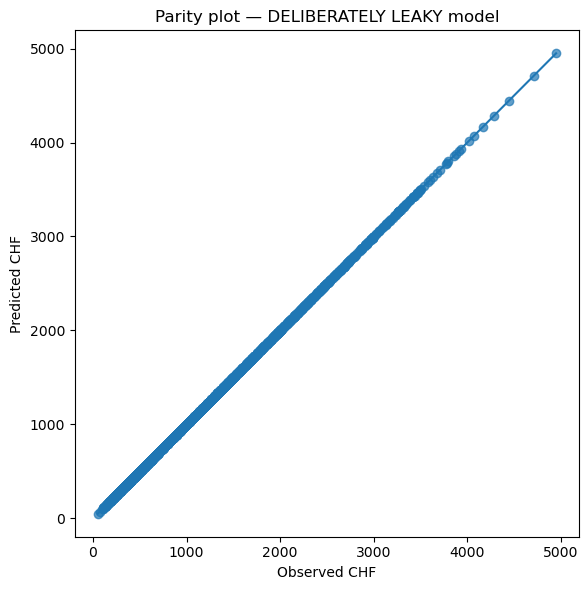

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, leaky_test_pred, alpha=0.7)
lims = [
    min(float(np.min(y_test)), float(np.min(leaky_test_pred))),
    max(float(np.max(y_test)), float(np.max(leaky_test_pred))),
]
plt.plot(lims, lims)
plt.xlabel("Observed CHF")
plt.ylabel("Predicted CHF")
plt.title("Parity plot — DELIBERATELY LEAKY model")
plt.tight_layout()
plt.show()

### Discussion
- Why does the model now look unrealistically good?
- Would this performance be meaningful in practice?
- What kinds of real engineering features might accidentally leak target information?

## 18. Final checklist

You have completed Day 1 successfully if you have:

- loaded the data correctly;
- used the organiser-provided split;
- defined `X` and `y`;
- compared a naive baseline with Linear and Ridge Regression;
- produced a parity plot;
- produced a residual plot;
- written a short engineering interpretation.

> The main achievement of Day 1 is **not** model sophistication.  
> It is learning how to build a **correct and defensible baseline workflow**.

In [24]:
print("Day 1 Lab 1 notebook completed successfully.")
print("You now have a first defensible CHF baseline workflow.")

Day 1 Lab 1 notebook completed successfully.
You now have a first defensible CHF baseline workflow.
